# Background 

## Molecular dynamics
Molecular dynamics for an atomic system with Hamiltonian $H(R)$ is a kind of computer simulation that evolves the system in time according to Newton's laws of motion. The equation of motion is, for example, 

$m \frac{d^2 R}{dt^2} = \nabla_R H(R) - \lambda \frac{dR}{dt} + \xi(t)$

Here $\lambda$ is a friction coefficient, and $\xi(t)$ is a random force with Gaussian distribution. 
The term $-\lambda \frac{dR}{dt}$ and $\xi(t)$ together ensure the trajectory of $R$ samples the canonical ensemble at temperature $T$. 


## free energy calculation with metadynamics
We have a neural network model for interatomic potential $H(R)$ for any given configuration $R$ of single-crystal PbTiO3. We also have a model of the polarization vector $\mathcal{P}(R)$ for any given configuration $R$.

We already obtain the free energy surface $g(T, \mathcal{P})$ ($T$ is temperature, $\mathcal{P}$ is polarization vector) associated with $H(R)$ through

$g(T, \mathcal{P}) = - \frac{1}{k_B T} \ln \int dR \exp(-\beta H(R)) \delta(\mathcal{P} - \mathcal{P}(R))$

This free energy surface is calculated by metadynamics simulation. 

The so called metadynamic simulation is a kind of enhanced molecular dynamics simulation. What it differs from the normal MD simulation is that it adds a bias potential to the system. So instead of evolving under the original potential $H(R)$, the system evolves under the effective potential $H(R) + V(\mathcal{P}(R))$. 
The biasing potential $V$ is an explicit function of the polarization vector $\mathcal{P}(R)$. And because the polarization vector is a function of the configuration $R$, the biasing potential is eventually a function of the configuration $R$. 

A metadynamic simulation starts with $V(\mathcal{P}(R))=0$. As the simulation progresses, the biasing potential $V$ is gradually updated based on the history of the polarization vector $\mathcal{P}(R)$ sampled through the molecular dynamics simulation. The rule of updating $V$ is designed in a clever way, such that after a very long simulation, $V$ will converge to the free energy surface $g(T, \mathcal{P})$. Understanding this is enough for the purpose here.  

# Goal
Knowing $g(T, \mathcal{P})$, we would like to further determine the 6D free energy surface $f(T, P, \eta)$ for any given temperature $T$, polarization vector $\mathcal{P}$, and orthogonal strain tensor $\eta$. $\eta$ is the first three components in the full strain tensor $\eta_{all}=(\eta_{xx}, \eta_{yy}, \eta_{zz}, \eta_{xy}, \eta_{xz}, \eta_{yz})$. 

The free energy surface $F(T, \mathcal{P}, \eta)$ is defined based on the following `thermodynamic consistency relation`

$\exp(-\beta g(T, \mathcal{P})) = \int d\eta \exp(-\beta f(T, \mathcal{P}, \eta))$

This relation stands for the requirement that the expectation of any observation $O(\mathcal{P})$ associate to the distribution $\exp(-\beta g(T, \mathcal{P}))$ matches the expectation of $O(\mathcal{P})$ associate to the distribution $\exp(-\beta f(T, \mathcal{P}, \eta))$. In probability theory terms, the distribution $\exp(-\beta g(T, \mathcal{P}))$ is the marginal distribution of $\exp(-\beta f(T, \mathcal{P}, \eta))$.  And furthermore, $\exp(-\beta f(T, \mathcal{P}, \eta))$ is also a marginal distribution of the all-atom Boltzmann distribution $\exp(-\beta H(R))$. 

# How
An ansatz of $f(T, P, \eta)$ that is compatible with the `thermodynamic consistency relation` is

$f(T, \mathcal{P}, \eta) = g(T, \mathcal{P}) + .....  $  (see Eq.3 in paper)

# Note

X, Y, Z directions in this code is the Z, Y, X directions in the paper.















In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
## make ticks towards the inside
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
## set linewidth of the axes
mpl.rcParams['axes.linewidth'] = 1.5
e2C = 1.60217662e-19
e2uC = e2C * 1e6
Atcm=1e-8

temp_list= np.array([600, 700, 800, 820, 900, 1000])


# Data loading

In [2]:
polar_x_all_temp = {}
polar_y_all_temp = {}
polar_z_all_temp = {}
latt_x_all_temp = {}
latt_y_all_temp = {}
latt_z_all_temp = {}

for temp in temp_list:
    ## load data from metadynamics simulation
    folder = r'../FES_3D/data/{}K9x9x9'.format(temp)
    plumed_stride = 10
    dt = 0.0005 * 1000
    throw = int(10/dt)
    plumed_out = np.loadtxt(os.path.join(folder, 'COLVAR'))[::plumed_stride]
    thermo_out = np.loadtxt(os.path.join(folder, 'pto.log'), skiprows=58, max_rows=plumed_out.shape[0])
    polar_x = plumed_out[throw:,  5 ]* e2uC / Atcm**2 ## P_y of sampled trajectory, shape (#frames)
    polar_y = plumed_out[throw:,  6 ]* e2uC / Atcm**2 ## P_z of sampled trajectory, shape (#frames)
    polar_z = plumed_out[throw:,  7 ]* e2uC / Atcm**2 ## P_x of sampled trajectory, shape (#frames)
    latt_x = thermo_out[throw:,  -3 ] / 9.0 ## average lattice constant along x-direction, from sampled trajectory, shape (#frames)
    latt_y = thermo_out[throw:,  -2 ] / 9.0 ## average lattice constant along y-direction, from sampled trajectory, shape (#frames)
    latt_z = thermo_out[throw:,  -1 ] / 9.0 ## average lattice constant along z-direction, from sampled trajectory, shape (#frames)
    polar_x_all_temp['{:d}K'.format(temp)] = polar_x
    polar_y_all_temp['{:d}K'.format(temp)] = polar_y
    polar_z_all_temp['{:d}K'.format(temp)] = polar_z
    latt_x_all_temp['{:d}K'.format(temp)] = latt_x
    latt_y_all_temp['{:d}K'.format(temp)] = latt_y
    latt_z_all_temp['{:d}K'.format(temp)] = latt_z



# fitting 

/tmp/ipykernel_303144/3141323131.py:22: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  optimal_coef, _, rank, s = np.linalg.lstsq(variables, target)


Z1=7.682151232326716e-06, Z2=-2.170044274678974e-06, lref_z=3.941867438458066, lref_x or y=3.941867438458066


<Figure size 640x480 with 0 Axes>

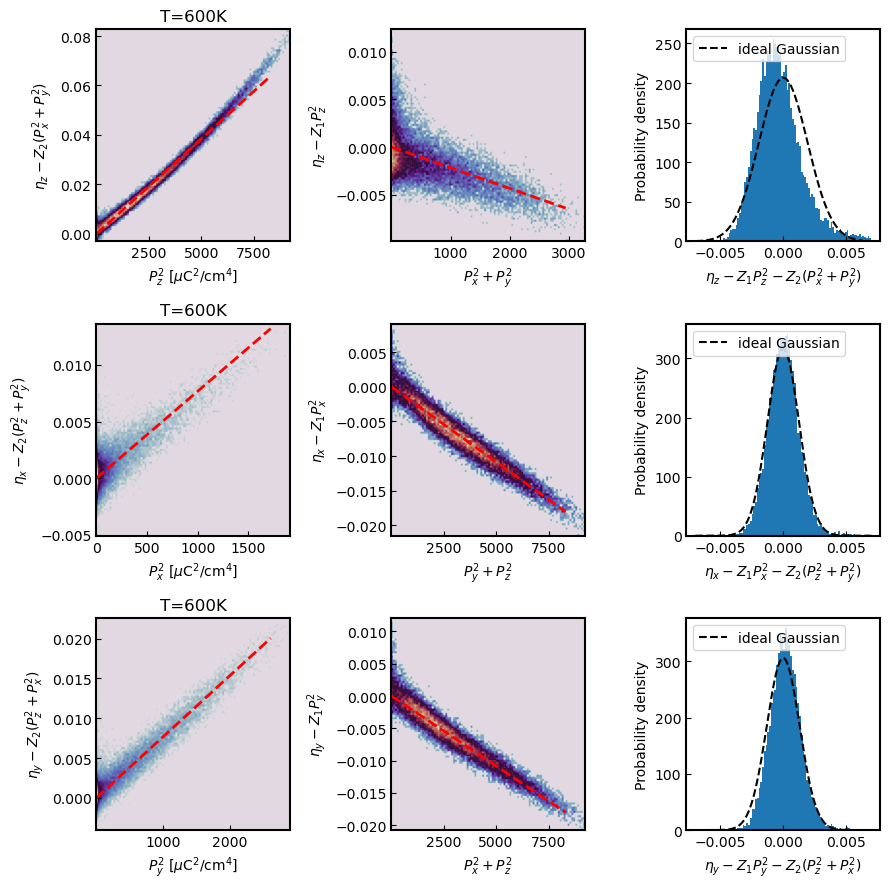

cov [[ 3.72631812e-06 -4.53577078e-07 -3.98371500e-07]
 [-4.53577078e-07  1.59198308e-06 -2.76500902e-07]
 [-3.98371500e-07 -2.76500902e-07  1.70425718e-06]]
Z1=7.740205513935399e-06, Z2=-2.2907750292098864e-06, lref_z=3.94699880531885, lref_x or y=3.94699880531885


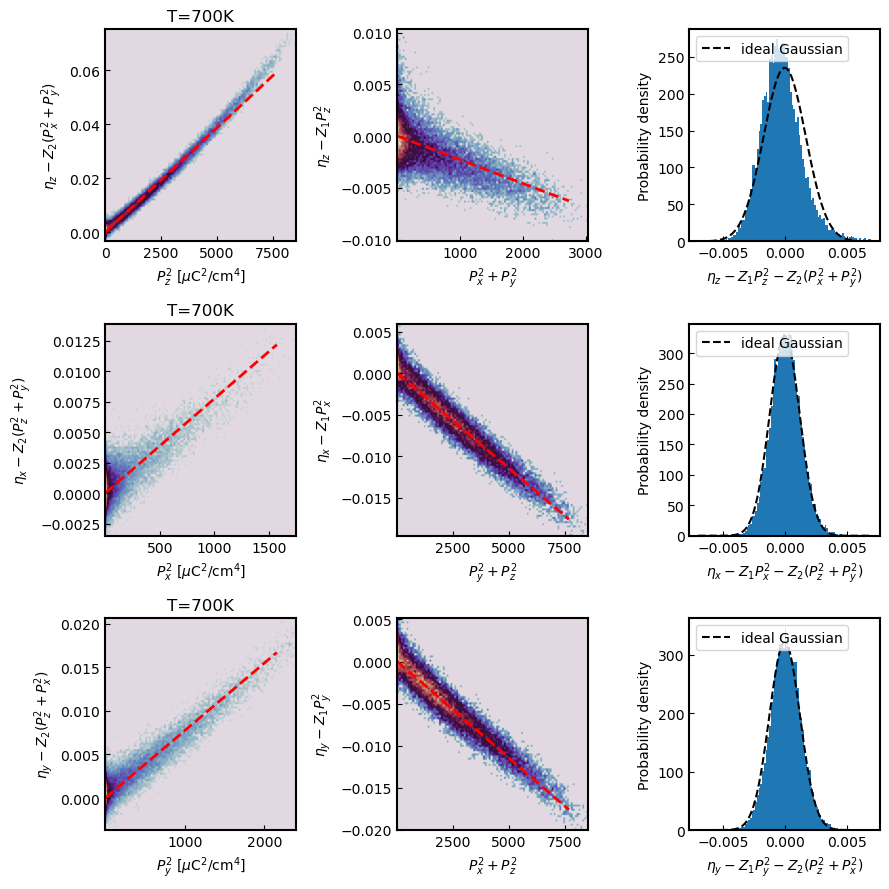

cov [[ 2.88869810e-06 -4.24090049e-07 -4.15091437e-07]
 [-4.24090049e-07  1.47814121e-06 -2.65436053e-07]
 [-4.15091437e-07 -2.65436053e-07  1.53995757e-06]]
Z1=7.814605598603261e-06, Z2=-2.414929044284818e-06, lref_z=3.952152287549969, lref_x or y=3.952152287549969


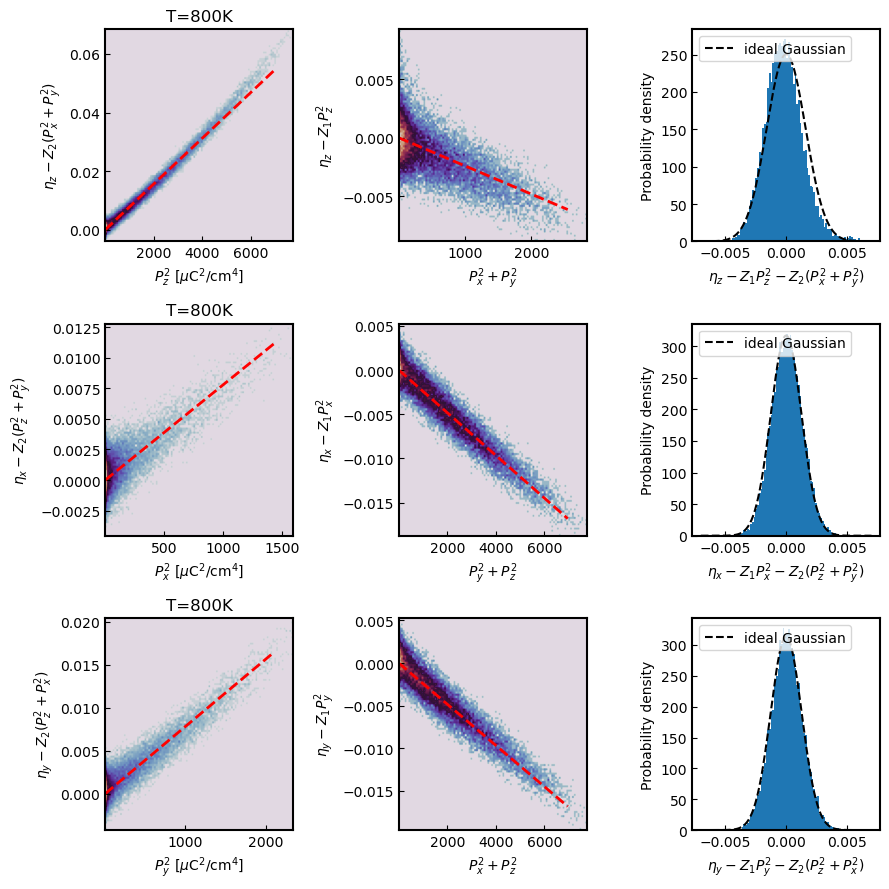

cov [[ 2.53610505e-06 -5.05299360e-07 -5.06635330e-07]
 [-5.05299360e-07  1.58599291e-06 -3.91639041e-07]
 [-5.06635330e-07 -3.91639041e-07  1.61511643e-06]]
Z1=7.83252812050203e-06, Z2=-2.436209169528374e-06, lref_z=3.953150488486339, lref_x or y=3.953150488486339


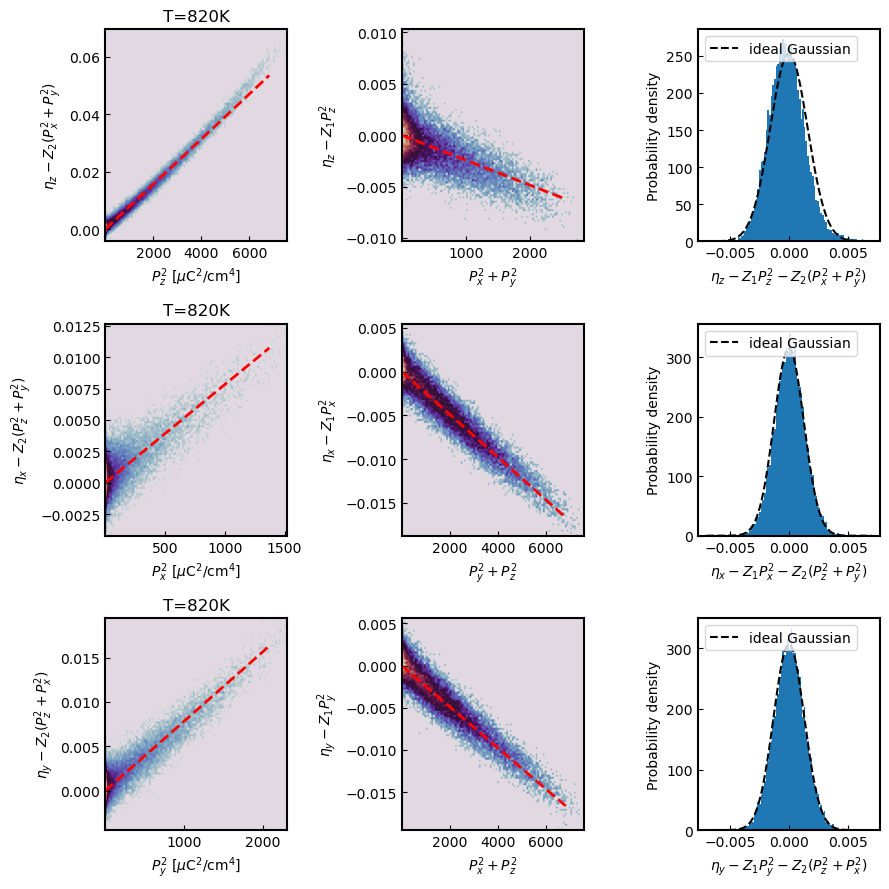

cov [[ 2.49025150e-06 -5.30368197e-07 -5.63026025e-07]
 [-5.30368197e-07  1.60061766e-06 -4.01986701e-07]
 [-5.63026025e-07 -4.01986701e-07  1.69019619e-06]]
Z1=7.91859345784409e-06, Z2=-2.540071866700325e-06, lref_z=3.957172399182316, lref_x or y=3.957172399182316


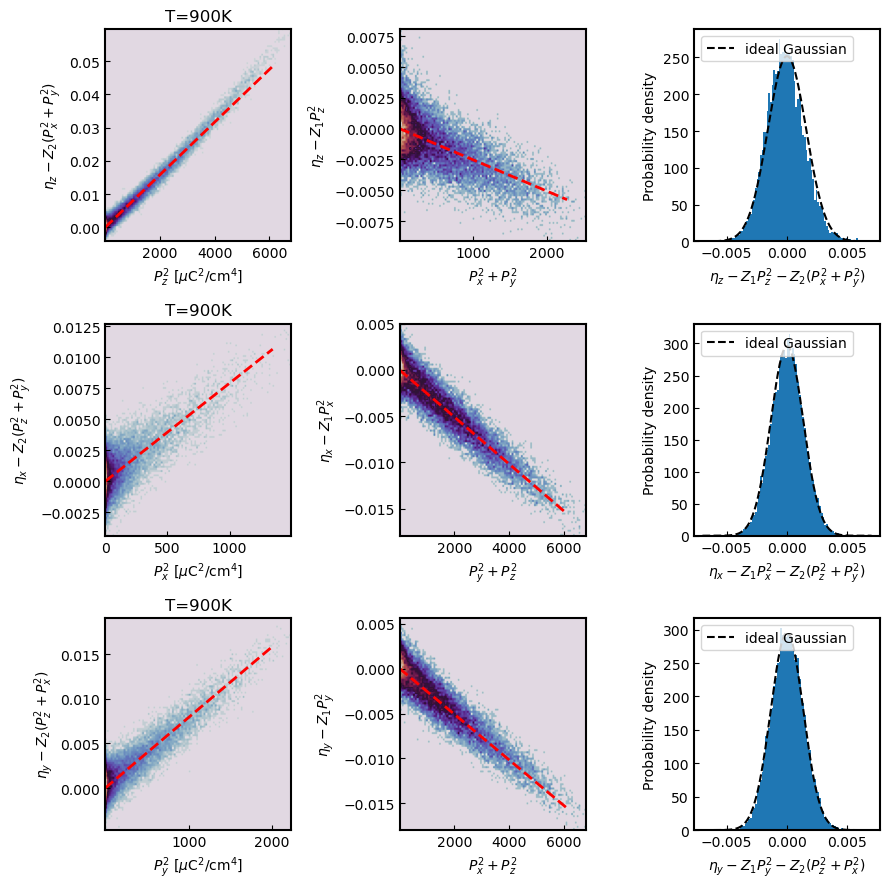

cov [[ 2.51012291e-06 -6.68715541e-07 -6.20436611e-07]
 [-6.68715541e-07  1.81676936e-06 -4.89480761e-07]
 [-6.20436611e-07 -4.89480761e-07  1.82321004e-06]]
Z1=8.052471117304607e-06, Z2=-2.6666313743796725e-06, lref_z=3.9622054704064413, lref_x or y=3.9622054704064413


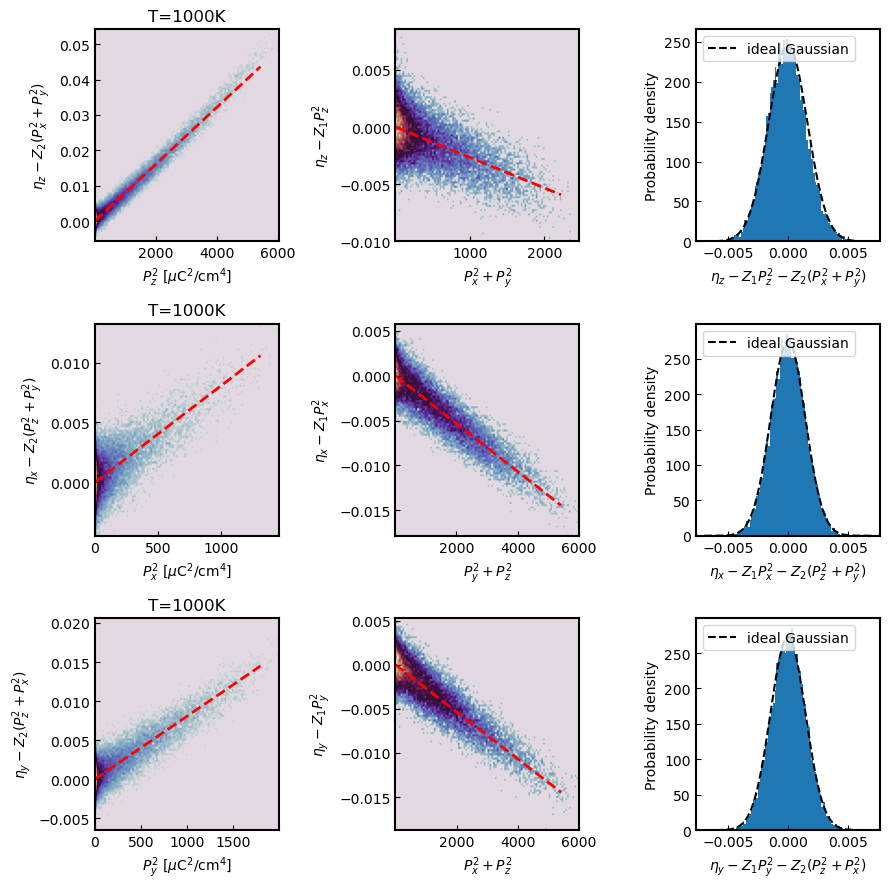

cov [[ 2.63815861e-06 -7.69001020e-07 -7.97759042e-07]
 [-7.69001020e-07  2.09948912e-06 -6.08372067e-07]
 [-7.97759042e-07 -6.08372067e-07  2.13549184e-06]]


In [3]:
lref_list = []
B11_list = []
B12_list = []
Z1_list = []
Z2_list = []

plt.set_cmap('twilight')
for temp in  [600, 700, 800, 820, 900, 1000]:
    polar_x = polar_x_all_temp['{:d}K'.format(temp)] ## P_y of sampled trajectory, shape (#frames)
    polar_y = polar_y_all_temp['{:d}K'.format(temp)] ## P_z of sampled trajectory, shape (#frames)
    polar_z = polar_z_all_temp['{:d}K'.format(temp)] ## P_x of sampled trajectory, shape (#frames)
    latt_x = latt_x_all_temp['{:d}K'.format(temp)] ## average lattice constant along x-direction, from sampled trajectory, shape (#frames)
    latt_y = latt_y_all_temp['{:d}K'.format(temp)] ## average lattice constant along y-direction, from sampled trajectory, shape (#frames)
    latt_z = latt_z_all_temp['{:d}K'.format(temp)] ## average lattice constant along z-direction, from sampled trajectory, shape (#frames)

    variable_sector_1 = np.stack((polar_z**2, polar_x**2 + polar_y**2, np.ones_like(polar_z)), axis=1)  # (nframes, 3)
    variable_sector_2 = np.stack((polar_x**2, polar_z**2 + polar_y**2, np.ones_like(polar_x)), axis=1)  # (nframes, 3)
    variable_sector_3 = np.stack((polar_y**2, polar_x**2 + polar_z**2, np.ones_like(polar_y)), axis=1)  # (nframes, 3)
    variables = np.concatenate((variable_sector_1, variable_sector_2, variable_sector_3), axis=0)  # (3*nframes, 3)
    target = np.concatenate([latt_z, latt_x, latt_y], axis=0)  # (3*nframes)

    optimal_coef, _, rank, s = np.linalg.lstsq(variables, target)
    lref_z = optimal_coef[2]
    lref_x = lref_z
    lref_y = lref_z
    Z1 = optimal_coef[0] / optimal_coef[2]
    Z2 = optimal_coef[1] / optimal_coef[2]
    Z1_list.append(Z1)
    Z2_list.append(Z2)
    print('Z1={}, Z2={}, lref_z={}, lref_x or y={}'.format(Z1, Z2, lref_z, lref_x))
    lref_list.append(lref_z)

    # calculate strain_z
    strain_z = (latt_z - lref_z) / lref_z
    strain_x = (latt_x - lref_x) / lref_x
    strain_y = (latt_y - lref_y) / lref_y
    residuals_z = strain_z - Z1 * polar_z**2 - Z2 * (polar_x**2 + polar_y**2)
    residuals_x = strain_x - Z1 * polar_x**2 - Z2 * (polar_z**2 + polar_y**2)
    residuals_y = strain_y - Z1 * polar_y**2 - Z2 * (polar_z**2 + polar_x**2)

    # visualize 2D hist polar_z**2 and strain_z
    fig, axs = plt.subplots(3, 3, figsize=(9, 9))
    ax = axs[0,0]
    hist2d, xedges, yedges = np.histogram2d(polar_z**2, strain_z - Z2 * (polar_x**2 + polar_y**2), bins=(100,100), density=True)
    im = ax.imshow((hist2d**0.5).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto')
    x_line = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
    y_line = Z1 * x_line 
    ax.plot(x_line, y_line, color='red', linewidth=2, label='Fit', linestyle='--')

    ax.set_title(f'T={temp}K')
    ax.set_xlabel(r'$P_z^2\ [\mu\mathrm{C}^2/\mathrm{cm}^4]$')
    ax.set_ylabel(r'$\eta_z - Z_2 (P_x^2 + P_y^2)$')

    # visualize 2D hist polar_x, strain_z and optimal fitting B
    ax = axs[0,1]
    hist2d, xedges, yedges = np.histogram2d(polar_x**2 + polar_y**2, strain_z - Z1 * polar_z**2, bins=(100,100), density=True)
    im = ax.imshow((hist2d**0.5).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto')
    x = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
    y = Z2 * x
    ax.plot(x, y, 'r', lw=2, label=r'$\eta_{\rm eq}=-\frac{B_{1xx}}{B_{11}}P^2$', linestyle='--')

    ax.set_xlabel(r'$P_x^2 + P_y^2$')
    ax.set_ylabel(r'$\eta_z - Z_1 P_z^2$')
  
    # visualize 1D hist strain_z - B*(polar_z**2) and gaussian 
    ax = axs[0,2]
    counts, bins, _ = ax.hist(residuals_z, bins=100, range=(-0.007, 0.007), density=True)
    mu = 0.0
    sigma = np.sqrt(np.var(residuals_z))
    x = np.linspace(bins[0], bins[-1] * 0.9, 200)
    gauss = 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-0.5*((x-mu)/sigma)**2)
    ax.plot(x, gauss, 'k--', label='ideal Gaussian')

    ax.set_xlabel(r'$\eta_z - Z_1 P_z^2 - Z_2 (P_x^2 + P_y^2)$')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper left')
 

    ax = axs[1,0]
    hist2d, xedges, yedges = np.histogram2d(polar_x**2, strain_x - Z2 * (polar_z**2 + polar_y**2), bins=(100,100), density=True)
    im = ax.imshow((hist2d**0.5).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto')
    x_line = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
    y_line = Z1 * x_line 
    ax.plot(x_line, y_line, color='red', linewidth=2, label='Fit', linestyle='--')
    ax.set_title(f'T={temp}K')
    ax.set_xlabel(r'$P_x^2\ [\mu\mathrm{C}^2/\mathrm{cm}^4]$')
    ax.set_ylabel(r'$\eta_x - Z_2 (P_z^2 + P_y^2)$')

    # visualize 2D hist polar_x, strain_z and optimal fitting B
    ax = axs[1,1]
    hist2d, xedges, yedges = np.histogram2d(polar_y**2 + polar_z**2, strain_x - Z1 * polar_x**2, bins=(100,100), density=True)
    im = ax.imshow((hist2d**0.5).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto')
    x = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
    y = Z2 * x
    ax.plot(x, y, 'r', lw=2, label=r'$\eta_{\rm eq}=-\frac{B_{1xx}}{B_{11}}P^2$', linestyle='--')
    ax.set_xlabel(r'$P_y^2 + P_z^2$')
    ax.set_ylabel(r'$\eta_x - Z_1 P_x^2$')
  
    # visualize 1D hist strain_z - B*(polar_z**2) and gaussian 
    ax = axs[1,2]
    counts, bins, _ = ax.hist(residuals_x, bins=100, range=(-0.007, 0.007), density=True)
    mu = 0.0
    sigma = np.sqrt(np.var(residuals_x))
    x = np.linspace(bins[0], bins[-1], 200)
    gauss = 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-0.5*((x-mu)/sigma)**2)
    ax.plot(x, gauss, 'k--', label='ideal Gaussian')
    ax.set_xlabel(r'$\eta_x - Z_1 P_x^2 - Z_2 (P_z^2 + P_y^2)$')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper left')


    ax = axs[2,0]
    hist2d, xedges, yedges = np.histogram2d(polar_y**2, strain_y - Z2 * (polar_z**2 + polar_x**2), bins=(100,100), density=True)
    im = ax.imshow((hist2d**0.5).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto')
    x_line = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
    y_line = Z1 * x_line 
    ax.plot(x_line, y_line, color='red', linewidth=2, label='Fit', linestyle='--')
    ax.set_title(f'T={temp}K')
    ax.set_xlabel(r'$P_y^2\ [\mu\mathrm{C}^2/\mathrm{cm}^4]$')
    ax.set_ylabel(r'$\eta_y - Z_2 (P_z^2 + P_x^2)$')

    # visualize 2D hist polar_x, strain_z and optimal fitting B
    ax = axs[2,1]
    hist2d, xedges, yedges = np.histogram2d(polar_x**2 + polar_z**2, strain_y - Z1 * polar_y**2, bins=(100,100), density=True)
    im = ax.imshow((hist2d**0.5).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto')
    x = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
    y = Z2 * x
    ax.plot(x, y, 'r', lw=2, label=r'$\eta_{\rm eq}=-\frac{B_{1xx}}{B_{11}}P^2$', linestyle='--')
    ax.set_xlabel(r'$P_x^2 + P_z^2$')
    ax.set_ylabel(r'$\eta_y - Z_1 P_y^2$')
  
    # visualize 1D hist strain_z - B*(polar_z**2) and gaussian 
    ax = axs[2,2]
    counts, bins, _ = ax.hist(residuals_y, bins=100, range=(-0.007, 0.007), density=True)
    mu = 0.0
    sigma = np.sqrt(np.var(residuals_y))
    x = np.linspace(bins[0], bins[-1], 200)
    gauss = 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-0.5*((x-mu)/sigma)**2)
    ax.plot(x, gauss, 'k--', label='ideal Gaussian')
    ax.set_xlabel(r'$\eta_y - Z_1 P_y^2 - Z_2 (P_z^2 + P_x^2)$')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    # Z
    Z = np.array([
        [Z1, Z2, Z2],
        [Z2, Z1, Z2],
        [Z2, Z2, Z1],
    ])

    # finding B11 and B12
    fluctuations = np.stack([
        residuals_z,
        residuals_x,
        residuals_y
    ], axis=1)
    cov = np.cov(fluctuations, rowvar=False)
    V1 = np.mean([cov[0,0], cov[1,1], cov[2,2]])
    V2 = np.mean([cov[0,1], cov[0,2], cov[1,2]])
    # V1 = np.mean([cov[1,1], cov[2,2]])
    print('cov', cov)
    V = np.array([
        [V1, V2, V2],
        [V2, V1, V2],
        [V2, V2, V1]
    ])
    k_B = 8.617333262e-5 #eV/K
    B = (k_B * temp) / 9**3 * np.linalg.inv(V)
    B11 = B[0,0]
    B12 = B[0,1]
    B11_list.append(B11)
    B12_list.append(B12)
 
    



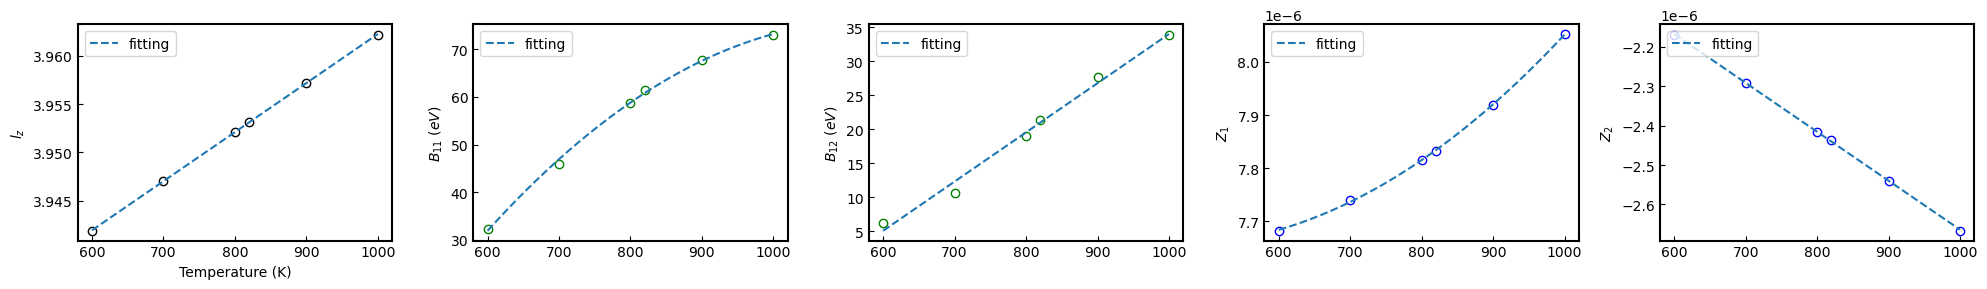

In [4]:
# fitting all the parameters, finding the T dependent relationship
# B11_elastic = np.array(B11_list) * 1.60218e-19 / 64.0e-30 / 1e9  # from eV to elastic module in unit of GPa
# B12_elastic = np.array(B12_list) * 1.60218e-19 / 64.0e-30 / 1e9  # from eV to elastic module in unit of GPa


temp_fit = np.linspace(min(temp_list), max(temp_list), 200)
m_l, b_l = np.polyfit(temp_list, lref_list, 1)
a_b11, m_b11,  b_b11  = np.polyfit(temp_list, B11_list,  2)
m_b12,  b_b12  = np.polyfit(temp_list, B12_list,  1)
a_z1,m_z1, b_z1 = np.polyfit(temp_list, Z1_list, 2)
m_z2, b_z2 = np.polyfit(temp_list, Z2_list, 1)
fig, axes = plt.subplots(1, 5, figsize=(20, 3))

# 1) l_ref vs T
ax = axes[0]
ax.plot(temp_list, lref_list, 'o-', markerfacecolor='white', color='black', linewidth=0)
y = m_l * temp_fit + b_l
ax.plot(temp_fit, y, '--', label='fitting')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$l_z$')
ax.legend(loc='upper left') 

# 2) B11 vs T
ax = axes[1]
ax.plot(temp_list, B11_list, 'o-', markerfacecolor='white', color='g', linewidth=0)
y = a_b11 * temp_fit**2 + m_b11 * temp_fit + b_b11
ax.plot(temp_fit, y, '--', label='fitting')
ax.set_ylabel(r'$B_{11} \ (eV)$')
ax.legend(loc='upper left') 

# 3) B12 vs T
ax = axes[2]
ax.plot(temp_list, B12_list, 'o-', markerfacecolor='white', color='g', linewidth=0)
y = m_b12 * temp_fit + b_b12
ax.plot(temp_fit, y, '--', label='fitting')
ax.set_ylabel(r'$B_{12} \ (eV)$')
ax.legend(loc='upper left') 

# 4) Z1 vs T
ax = axes[3]
ax.plot(temp_list, Z1_list, 'o-', markerfacecolor='white', color='blue', linewidth=0)
y = a_z1 * temp_fit**2 + m_z1 * temp_fit + b_z1
ax.plot(temp_fit, y, '--', label='fitting')
ax.set_ylabel(r'$Z_1$')
ax.legend(loc='upper left')

# 5) Z2 vs T
ax = axes[4]
ax.plot(temp_list, Z2_list, 'o-', markerfacecolor='white', color='blue', linewidth=0)
y = m_z2 * temp_fit + b_z2
ax.plot(temp_fit, y, '--', label='fitting')
ax.set_ylabel(r'$Z_2$')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# With optimal parameters, study fitting error contribution to FES

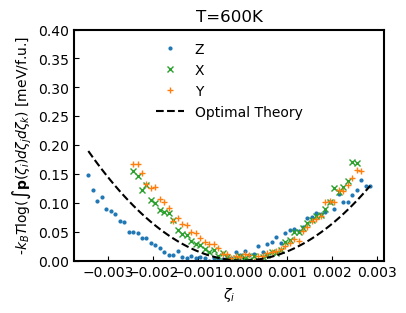

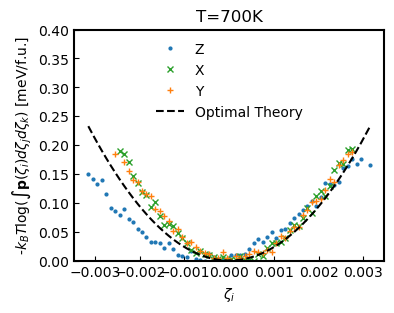

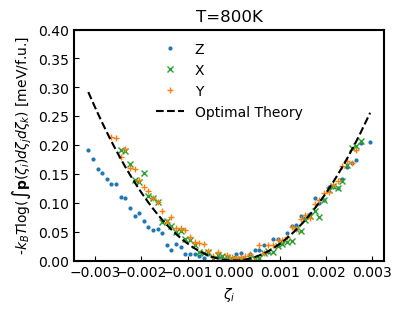

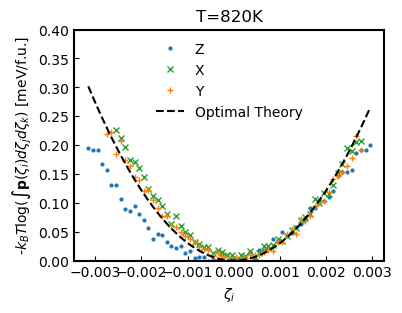

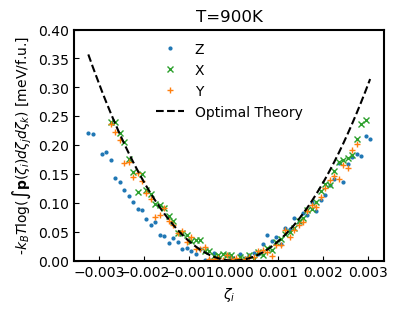

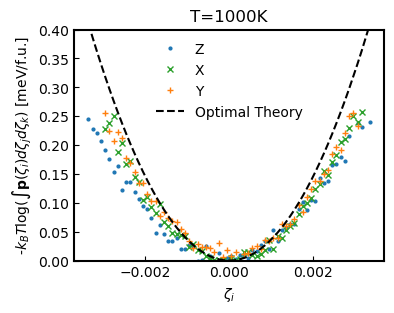

In [5]:

lref_fit = m_l * temp_list + b_l
B11_fit = a_b11 * temp_list**2 + m_b11 * temp_list + b_b11
B12_fit = m_b12 * temp_list + b_b12
Z1_fit = a_z1 * temp_list**2 + m_z1 * temp_list + b_z1
Z2_fit = m_z2 * temp_list + b_z2

nunits = 9 ** 3
lb, ub = -0.005, 0.005  ## lower and upper bound of the histogram of the residual
for idx, temp in enumerate(temp_list):
    polar_x = polar_x_all_temp['{:d}K'.format(temp)] ## P_y of sampled trajectory, shape (#frames)
    polar_y = polar_y_all_temp['{:d}K'.format(temp)] ## P_z of sampled trajectory, shape (#frames)
    polar_z = polar_z_all_temp['{:d}K'.format(temp)] ## P_x of sampled trajectory, shape (#frames)
    latt_x = latt_x_all_temp['{:d}K'.format(temp)] ## average lattice constant along x-direction, from sampled trajectory, shape (#frames)
    latt_y = latt_y_all_temp['{:d}K'.format(temp)] ## average lattice constant along y-direction, from sampled trajectory, shape (#frames)
    latt_z = latt_z_all_temp['{:d}K'.format(temp)] ## average lattice constant along z-direction, from sampled trajectory, shape (#frames)
    # get covariance matrix
    B = np.array([
        [B11_fit[idx], B12_fit[idx], B12_fit[idx]],
        [B12_fit[idx], B11_fit[idx], B12_fit[idx]],
        [B12_fit[idx], B12_fit[idx], B11_fit[idx]],
    ])
    cov = np.linalg.inv(B) * k_B * temp / 9**3
    


    strain_x = (latt_x - lref_fit[idx]) / lref_fit[idx]
    strain_y = (latt_y - lref_fit[idx]) / lref_fit[idx]
    strain_z = (latt_z - lref_fit[idx]) / lref_fit[idx]

    residuals_z = strain_z - Z1_fit[idx] * polar_z**2 - Z2_fit[idx] * (polar_x**2 + polar_y**2)
    residuals_x = strain_x - Z1_fit[idx] * polar_x**2 - Z2_fit[idx] * (polar_z**2 + polar_y**2)
    residuals_y = strain_y - Z1_fit[idx] * polar_y**2 - Z2_fit[idx] * (polar_z**2 + polar_x**2)

    # ## attemps to plot 3D FES. not sufficient data to get meaningful result
    # residuals_3D = np.stack([residuals_z, residuals_x, residuals_y], axis=1) # (nsample, 3)
    # hist3D, edges = np.histogramdd(residuals_3D, bins=50, range=((lb, ub), (lb, ub), (lb, ub)), density=False)
    # edges_z, edges_x, edges_y = edges
    # edges_z = 0.5 * (edges_z[:-1] + edges_z[1:])
    # edges_x = 0.5 * (edges_x[:-1] + edges_x[1:])
    # edges_y = 0.5 * (edges_y[:-1] + edges_y[1:])
    # mesh_z, mesh_x, mesh_y = np.meshgrid(edges_z, edges_x, edges_y, indexing='ij')
    # ## remove those without data
    # filter_3D = hist3D > 20
    # logP_3D = np.log(hist3D[filter_3D])
    # mesh_z = mesh_z[filter_3D]
    # mesh_x = mesh_x[filter_3D]
    # mesh_y = mesh_y[filter_3D]
    # mesh_combine = np.stack([mesh_z, mesh_x, mesh_y], axis=0) # (3, nsamples)
    # numerical_energy = -k_B * temp * (logP_3D - np.max(logP_3D)) * 1000 / nunits  ## in meV/fu
    # predicted_energy = 0.5 * (mesh_combine * (B @ mesh_combine)).sum(0) * 1000 ## in meV/fu

    # fig, axs = plt.subplots(1, 1, figsize=(4,3))
    # axs.scatter(numerical_energy, predicted_energy, s=1)
    # maxval = max(numerical_energy.max(), predicted_energy.max())
    # axs.set_xlim(0, maxval)
    # axs.set_ylim(0, maxval)
    # ## plot diagonal line
    # axs.plot([0, maxval], [0, maxval], 'k--')
    # axs.set_xlabel('Numerical energy [meV/fu]')
    # axs.set_ylabel('Predicted energy [meV/fu]')
    # axs.set_title(f'T={temp}K')
    # plt.show()

    # ## attemps to plot 2D FES.   not sufficient data to get meaningful result
    # residuals_2D = np.stack([residuals_z,  residuals_y], axis=1) # (nsample, 2)
    # hist2D, edges_z, edges_y = np.histogram2d(residuals_2D[:,0], residuals_2D[:,1], bins=50, range=((lb, ub), (lb, ub)), density=False)
    # print('max of hist2D', hist2D.max())
    # edges_z = 0.5 * (edges_z[:-1] + edges_z[1:])
    # edges_y = 0.5 * (edges_y[:-1] + edges_y[1:])
    # mesh_z, mesh_y = np.meshgrid(edges_z, edges_y, indexing='ij')
    # ## remove those without data
    # filter_2D = hist2D > 20
    # logP_2D = np.log(hist2D[filter_2D])
    # mesh_z = mesh_z[filter_2D]
    # mesh_y = mesh_y[filter_2D]
    # mesh_combine = np.stack([mesh_z, mesh_y], axis=0) # (2, nsamples)
    # numerical_energy = -k_B * temp * (logP_2D - np.max(logP_2D)) * 1000 / nunits  ## in meV/fu
    # predicted_energy = 0.5 * (mesh_combine * (B[:2,:2] @ mesh_combine)).sum(0) * 1000 ## in meV/fu

    # fig, axs = plt.subplots(1, 1, figsize=(4,3))
    # axs.scatter(numerical_energy, predicted_energy, s=1)
    # maxval = max(numerical_energy.max(), predicted_energy.max())
    # axs.set_xlim(0, maxval)
    # axs.set_ylim(0, maxval)
    # ## plot diagonal line
    # axs.plot([0, maxval], [0, maxval], 'k--')
    # axs.set_xlabel('Numerical energy [meV/fu]')
    # axs.set_ylabel('Predicted energy [meV/fu]')
    # axs.set_title(f'T={temp}K')
    # plt.show()

    ## get the histogram and the corresponding logP
    hist_z, bins_z = np.histogram(residuals_z, bins=100, range=(lb, ub), density=False)
    hist_x, bins_x = np.histogram(residuals_x, bins=100, range=(lb, ub), density=False)
    hist_y, bins_y = np.histogram(residuals_y, bins=100, range=(lb, ub), density=False)
    ## remove those too few data
    filter_z = hist_z > 50
    filter_x = hist_x > 50
    filter_y = hist_y > 50
    ## compute logP
    logP_z = np.log(hist_z[filter_z])  
    logP_x = np.log(hist_x[filter_x])
    logP_y = np.log(hist_y[filter_y])
    bins_z = 0.5 * (bins_z[:-1] + bins_z[1:])[filter_z]
    bins_x = 0.5 * (bins_x[:-1] + bins_x[1:])[filter_x]
    bins_y = 0.5 * (bins_y[:-1] + bins_y[1:])[filter_y]
    ## compute corresponding free energy
    numerical_energy_z = -k_B * temp * (logP_z - np.max(logP_z)) * 1000 / nunits  ## in meV/fu
    numerical_energy_x = -k_B * temp * (logP_x - np.max(logP_x)) * 1000 / nunits
    numerical_energy_y = -k_B * temp * (logP_y - np.max(logP_y)) * 1000 / nunits
    predicted_energy_z = 0.5 * bins_z**2 * B[0,0] * 1000
    predicted_energy_x = 0.5 * bins_x**2 * B[1,1] * 1000
    predicted_energy_y = 0.5 * bins_y**2 * B[2,2] * 1000
 
    fig, axs = plt.subplots(1, 1, figsize=(4, 3))
    axs.plot(bins_z, numerical_energy_z, 'o-', color='tab:blue', linewidth=0, label='Z', markersize=2)
    axs.plot(bins_x, numerical_energy_x, 'x-', color='tab:green', linewidth=0, label='X', markersize=4)
    axs.plot(bins_y, numerical_energy_y, '+-', color='tab:orange', linewidth=0, label='Y', markersize=4)
    axs.plot(bins_z, predicted_energy_z, '--', label='Optimal Theory', color='black')
    axs.set_ylim(0,0.4)
    axs.set_xlabel(r'$\zeta_i$')
    axs.set_ylabel(r'-$k_BT \log (\int\mathbf{p}(\zeta_i) d\zeta_j d\zeta_k)$ [meV/f.u.]')
    axs.set_title(f'T={temp}K')
    axs.legend(loc='upper center', frameon=False)




# plot figure used in paper

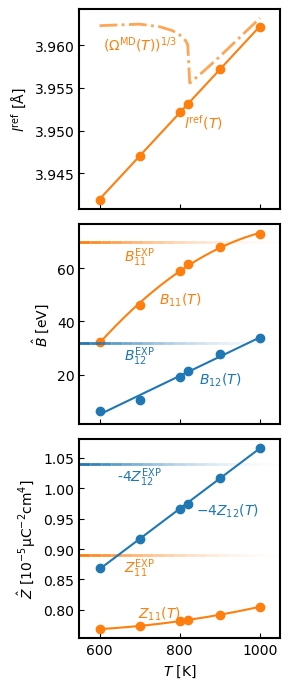

In [6]:
### experimental elastic modulus
elastic_scale_factor =  1.60218e-19 / 64.0e-30 / 1e9  # from eV to elastic module in unit of GPa
elastic_compliance = np.array([[8.0, -2.5, -2.5],[-2.5, 8.0, -2.5],[-2.5, -2.5, 8.0]])
elastic_module_exp = np.linalg.inv(elastic_compliance) * 1000   # GPa
elastic_module_exp = elastic_module_exp / elastic_scale_factor  # eV
exp_B11 = elastic_module_exp[0,0]
exp_B12 = elastic_module_exp[0,1]

### direct MD calculation of lattice constants,  Ref: PHYSICAL REVIEW B 111, 094113 (2025)
MD_temp = np.array([300, 400, 500, 600, 700, 750, 780, 790, 800, 810, 815, 820, 825, 830, 840, 850, 860, 870, 900, 1000])
MD_cubic_root_vol = np.array([3.9595046, 3.96067265, 3.96164924, 3.96232579, 3.96250239, 3.96219918, 
                     3.96177188, 3.9615371, 3.96123298, 3.96081748, 3.96052969, 3.96006569, 
                     3.95557812, 3.95576626, 3.95617662, 3.95657426, 3.95699458, 3.95740965, 
                     3.95870457, 3.96321657])



temp_fit = np.linspace(min(temp_list), max(temp_list), 200)
fig, axes = plt.subplots(3, 1, figsize=(3, 7), sharex=True)

# 1) l_ref vs T
ax = axes[0]
## plot experimental lattice constant
# ax.plot(exp_a_temp_dense_paraelectric, exp_a_const_dense_paraelectric, '--', markersize=0, color='blue', alpha = 0.3,linewidth=2)
# ax.plot(exp_root_vol_temp, exp_root_vol, '-.', markersize=0, color='tab:blue', alpha = 0.5,linewidth=2, label=r'$(\Omega^{\text{EXP}})^{1/3}$')
ax.plot(MD_temp[MD_temp>599], MD_cubic_root_vol[MD_temp>599], linestyle='-.', markersize=0, color='tab:orange', alpha = 0.7,linewidth=2, label=r'$(\Omega^{\text{MD}})^{1/3}$')
ax.annotate(r'$(\Omega^{\text{MD}}(T))^{1/3}$', xy=(600, 3.96), xytext=( 700, 3.959 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
ax.plot(temp_list, lref_list, 'o-',  color='tab:orange', linewidth=0, label=r'$l^{\text{ref}}$')
# ax.legend(frameon=False)
## plot fitting result
y = m_l * temp_fit + b_l
ax.plot(temp_fit, y, '-', color='tab:orange')
ax.annotate(r'$l^{\text{ref}}(T)$', xy=(800, 3.95), xytext=( 860, 3.95 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
ax.set_ylabel(r'$l^{\text{ref}}$ [$\mathrm{\AA}$]')
ax.set_xlim(550, 1050)
# ax.legend(  frameon=False) 

# 2) B11 vs T
ax = axes[1]
## plot B11
ax.plot(temp_list, B11_list, 'o-',   color='tab:orange', linewidth=0, label=r'$B_{11}(T)$')
y = a_b11 * temp_fit**2 + m_b11 * temp_fit + b_b11
ax.plot(temp_fit, y, '-', color='tab:orange')
ax.annotate(r'$B_{11}(T)$', xy=(600, 65), xytext=(800, 45 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
## plot B11 experimental value
x_range = ax.get_xlim()
x_points = np.linspace(x_range[0], x_range[1], 20)
for i in range(len(x_points)-1):
    alpha = (1 - i/len(x_points))**2
    ax.plot([x_points[i], x_points[i+1]], [exp_B11, exp_B11], 
            linestyle='-.', color='tab:orange', alpha=alpha, linewidth=2)
ax.annotate(r'$B_{11}^{\text{EXP}}$', xy=(600, 65), xytext=(700, 60 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
## plot B12
ax.plot(temp_list, B12_list, 'o-', color='tab:blue', linewidth=0, label=r'$B_{12}(T)$')
y = m_b12 * temp_fit + b_b12
ax.plot(temp_fit, y, '-', color='tab:blue')
ax.annotate(r'$B_{12}(T)$', xy=(600, 65), xytext=(900, 15 ), color='tab:blue', alpha=1,fontsize=10, ha='center', va='bottom')
## plot B12 experimental value: gradient line by plotting multiple segments with decreasing alpha
x_range = ax.get_xlim()
x_points = np.linspace(x_range[0], x_range[1], 20)
for i in range(len(x_points)-1):
    alpha = (1 - i/len(x_points))**2
    ax.plot([x_points[i], x_points[i+1]], [exp_B12, exp_B12], 
            linestyle='-.', color='tab:blue', alpha=alpha, linewidth=2)
ax.annotate(r'$B_{12}^{\text{EXP}}$', xy=(600, 30), xytext=(700, 23 ), color='tab:blue', alpha=1,fontsize=10, ha='center', va='bottom')
ax.set_ylabel(r'$\hat{B}$ [eV]')
# ax.legend( loc='upper left', frameon=False, fontsize=9, labelspacing=0.15) 
 
# 3) Z1 vs T
ax = axes[2]
Z1_exp = 0.089 * 1e-4 * 1e5   # Citation: J. Appl. Phys. 62, 3331 (1987); doi: 10.1063/1.339293
Z12_exp = -0.026 * 1e-4 * 1e5
## plot Z1 first
ax.plot(temp_list, np.array(Z1_list) * 1e5, 'o-', color='tab:orange', linewidth=0, label=r'$Z_{11}(T)$')
ax.annotate(r'$Z_{11}(T)$', xy=(600, 1.00), xytext=(750, 0.78 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
y = a_z1 * temp_fit**2 + m_z1 * temp_fit + b_z1
ax.plot(temp_fit, y * 1e5, '-', color='tab:orange')
## plot Z1 experimental value
x_range = ax.get_xlim()
x_points = np.linspace(x_range[0], x_range[1], 20)
for i in range(len(x_points)-1):
    alpha = (1 - i/len(x_points))**2
    ax.plot([x_points[i], x_points[i+1]], [Z1_exp, Z1_exp], 
            linestyle='-.', color='tab:orange', alpha=alpha, linewidth=2)
ax.annotate(r'$Z_{11}^{\text{EXP}}$', xy=(900, 0.85), xytext=(700, 0.85 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
## plot Z2
ax.plot(temp_list, -4 * np.array(Z2_list) * 1e5, 'o-',  color='tab:blue', linewidth=0, label=r'$-4Z_{12}(T)$')
ax.annotate(r'$-4Z_{12}(T)$', xy=(800, 0.95), xytext=(920, 0.95 ), color='tab:blue', alpha=1,fontsize=10, ha='center', va='bottom')
y = m_z2 * temp_fit + b_z2
ax.plot(temp_fit, -4 * y * 1e5, '-', color='tab:blue')
## plot Z2 experimental value
x_range = ax.get_xlim()
x_points = np.linspace(x_range[0], x_range[1], 20)
for i in range(len(x_points)-1):
    alpha = (1 - i/len(x_points))**2
    ax.plot([x_points[i], x_points[i+1]], [-4 * Z12_exp, -4 * Z12_exp], 
            linestyle='-.', color='tab:blue', alpha=alpha, linewidth=2)
ax.annotate(r'-4$Z_{12}^{\text{EXP}}$', xy=(600, 1.00), xytext=(700, 1.00 ), color='tab:blue', alpha=1,fontsize=10, ha='center', va='bottom')

ax.set_ylabel(r'$\hat{Z}$ $[\mathrm{10^{-5}\mu C^{-2} cm ^4}]$')
# ax.legend( loc='upper left', frameon=False, fontsize=9, labelspacing=0.15) 
ax.set_xlabel(r'$T$ [K]')
plt.tight_layout()
plt.savefig('fit_results.png', dpi=300)  


/tmp/ipykernel_303144/2717685918.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(frameon=False)


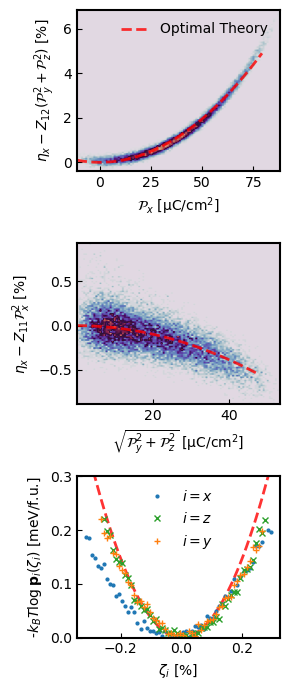

In [7]:
import matplotlib.colors as mcolors
temp = 800
idx = 2

fig, ax = plt.subplots(3, 1, figsize=(3, 7))
polar_x, polar_y, polar_z = polar_x_all_temp['{:d}K'.format(temp)], polar_y_all_temp['{:d}K'.format(temp)], polar_z_all_temp['{:d}K'.format(temp)]
latt_x, latt_y, latt_z = latt_x_all_temp['{:d}K'.format(temp)], latt_y_all_temp['{:d}K'.format(temp)], latt_z_all_temp['{:d}K'.format(temp)]
lref = lref_list[idx]
strain_x = (latt_x - lref) / lref
strain_y = (latt_y - lref) / lref
strain_z = (latt_z - lref) / lref
Z1, Z2 = Z1_fit[idx], Z2_fit[idx]
residuals_z = strain_z - Z1 * polar_z**2 - Z2 * (polar_x**2 + polar_y**2)
residuals_x = strain_x - Z1 * polar_x**2 - Z2 * (polar_z**2 + polar_y**2)
residuals_y = strain_y - Z1 * polar_y**2 - Z2 * (polar_z**2 + polar_x**2)
## get the histogram and the corresponding logP
lb, ub = -0.005, 0.005
hist_z, bins_z = np.histogram(residuals_z, bins=100, range=(lb, ub), density=False)
hist_x, bins_x = np.histogram(residuals_x, bins=100, range=(lb, ub), density=False)
hist_y, bins_y = np.histogram(residuals_y, bins=100, range=(lb, ub), density=False)
## remove those too few data
filter_z = hist_z > 50
filter_x = hist_x > 50
filter_y = hist_y > 50
## compute logP
logP_z = np.log(hist_z[filter_z])  
logP_x = np.log(hist_x[filter_x])
logP_y = np.log(hist_y[filter_y])
bins_z = 0.5 * (bins_z[:-1] + bins_z[1:])[filter_z]
bins_x = 0.5 * (bins_x[:-1] + bins_x[1:])[filter_x]
bins_y = 0.5 * (bins_y[:-1] + bins_y[1:])[filter_y]
## compute corresponding free energy
numerical_energy_z = -k_B * temp * (logP_z - np.max(logP_z)) * 1000 / nunits  ## in meV/fu
numerical_energy_x = -k_B * temp * (logP_x - np.max(logP_x)) * 1000 / nunits
numerical_energy_y = -k_B * temp * (logP_y - np.max(logP_y)) * 1000 / nunits
predicted_energy_z = 0.5 * bins_z**2 * B[0,0] * 1000
predicted_energy_x = 0.5 * bins_x**2 * B[1,1] * 1000
predicted_energy_y = 0.5 * bins_y**2 * B[2,2] * 1000


plt.set_cmap('twilight')

hist2d, xedges, yedges = np.histogram2d(polar_z, strain_z - Z2 * (polar_x**2 + polar_y**2), bins=(100,100), density=True)
im = ax[0].imshow((hist2d).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0]*100, yedges[-1]*100], aspect='auto', label='Histogram')
x_line = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
y_line = Z1 * x_line**2
ax[0].plot(x_line, y_line * 100, color='red', linewidth=2,  linestyle='--', alpha=0.8, label='Optimal Theory')
ax[0].set_xlabel(r'$\mathcal{P}_x$ $[\mathrm{\mu C/cm^2}]$')
ax[0].set_ylabel(r'$\eta_x - Z_{12} (\mathcal{P}_y^2 + \mathcal{P}_z^2)$ [%]')
ax[0].legend(frameon=False)
# cbar = plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04 )
# cbar.ax.tick_params(labelsize=12)

# visualize 2D hist polar_x, strain_z and optimal fitting B
hist2d, xedges, yedges = np.histogram2d( (polar_x**2 + polar_y**2)**0.5, strain_z - Z1 * polar_z**2, bins=(100,100), density=True)
im = ax[1].imshow((hist2d).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0]*100, yedges[-1]*100], aspect='auto')
x = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
# x = np.linspace(0,2500, 1000)
y = Z2 * x**2
ax[1].plot(x , y * 100, color='red', linewidth=2, linestyle='--', alpha=0.8)
# cbar = plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04 )
# cbar.ax.tick_params(labelsize=12)
ax[1].set_xlabel(r'$\sqrt{\mathcal{P}_y^2 + \mathcal{P}_z^2}$ $[\mathrm{\mu C/cm^2}]$')
ax[1].set_ylabel(r'$\eta_x - Z_{11} \mathcal{P}_x^2$ [%]')
ax[1].legend(frameon=False)

ax[2].plot(bins_z * 100, predicted_energy_z, '--',  color='red', linewidth=2, alpha=0.8,)
ax[2].plot(bins_z * 100, numerical_energy_z, 'o-', color='tab:blue', linewidth=0, label=r'$i=x$', markersize=2)
ax[2].plot(bins_x * 100, numerical_energy_x, 'x-', color='tab:green', linewidth=0, label=r'$i=z$', markersize=4)
ax[2].plot(bins_y * 100, numerical_energy_y, '+-', color='tab:orange', linewidth=0, label=r'$i=y$', markersize=4)
ax[2].set_xlabel(r'$\zeta_i$ [%]')
ax[2].set_ylabel(r'-$k_BT \log \mathbf{p}_i(\zeta_i)$ [meV/f.u.]')
ax[2].set_ylim(0,0.3)
ax[2].legend(loc='upper center', frameon=False, ncol=1)

plt.tight_layout()
plt.savefig('fit_validation.png', dpi=300)  